## 0. 환경 설정 및 데이터 불러오기


In [66]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [67]:
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

In [68]:
df = pd.read_csv("/Users/CHOIEUNSEO/Desktop/AI·AX 전문가 과정/프로젝트/data/merged_df.csv")
df.head()

,년,월,시도,거래량,기준금리,주택담보대출금리,아파트 매매가격지수,소비자물가지수
0,2020,1,서울특별시,6500,1.25,2.51,86.72,100.09
1,2020,2,서울특별시,8403,1.25,2.52,86.82,100.16
2,2020,3,서울특별시,4634,0.75,2.48,86.91,99.94
3,2020,4,서울특별시,3165,0.75,2.58,86.82,99.50
4,2020,5,서울특별시,5819,0.50,2.52,86.65,99.44


## 1. 데이터 검증

In [69]:
# shape
df.shape

(77, 8)

In [70]:
# 컬럼 확인
df.columns

Index(['년', '월', '시도', '거래량', '기준금리', '주택담보대출금리', '아파트 매매가격지수', '소비자물가지수'], dtype='object')

In [71]:
# 데이터 타입
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   년           77 non-null     int64  
 1   월           77 non-null     int64  
 2   시도          77 non-null     object 
 3   거래량         77 non-null     int64  
 4   기준금리        77 non-null     float64
 5   주택담보대출금리    77 non-null     float64
 6   아파트 매매가격지수  77 non-null     float64
 7   소비자물가지수     77 non-null     float64
dtypes: float64(4), int64(3), object(1)
memory usage: 4.9+ KB


In [72]:
# 결측치 확인
df.isnull().sum()

년             0
월             0
시도            0
거래량           0
기준금리          0
주택담보대출금리      0
아파트 매매가격지수    0
소비자물가지수       0
dtype: int64

In [73]:
# 중복 확인
df.duplicated().sum()

np.int64(0)

In [74]:
# 기초 통계
df.describe()

,년,월,거래량,기준금리,주택담보대출금리,아파트 매매가격지수,소비자물가지수
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,2022.727273,6.272727,4575.792208,2.178571,3.709740,91.274805,109.423247
std,1.875299,3.489218,3034.958711,1.179497,0.736521,4.614684,6.419682
min,2020.000000,1.000000,577.000000,0.500000,2.390000,85.190000,99.440000
25%,2021.000000,3.000000,2556.000000,0.750000,2.880000,86.820000,102.750000
50%,2023.000000,6.000000,3997.000000,2.500000,3.960000,90.710000,110.520000
75%,2024.000000,9.000000,5819.000000,3.500000,4.270000,95.260000,114.650000
max,2026.000000,12.000000,16404.000000,3.500000,4.820000,102.710000,119.920000


In [75]:
df["년월"] = pd.to_datetime(
    df["년"].astype(str) + "-" +
    df["월"].astype(str).str.zfill(2)
)

## 2. EDA

In [76]:
fig = px.line(
    df,
    x="년월",
    y="거래량",
    title="서울 아파트 거래량 추이",
    markers=True
)

fig.update_layout(
    xaxis_title="년월",
    yaxis_title="거래량",
    hovermode="x unified"
)

fig.show()

In [77]:
fig = px.histogram(
    df,
    x="거래량",
    nbins=100,
    title="거래량 분포"
)

fig.show()

In [78]:
fig = px.box(
    df,
    y="거래량",
    title="거래량 Box Plot",
    points="outliers"
)

fig.show()

In [93]:
import plotly.express as px

fig = px.line(
    df,
    x="년월",
    y=["아파트 매매가격지수", "소비자물가지수"], 
    markers=True,
    title="아파트 매매가격지수 및 소비자물가지수 추이 비교"
)

fig.update_layout(
    yaxis_title="지수",
    legend_title_text="지표",
    hovermode="x unified" 
)

fig.show()

In [96]:
import plotly.express as px

fig = px.line(
    df,
    x="년월",
    y=["기준금리", "주택담보대출금리"], 
    markers=True,
    title="기준금리 및 주택담보대출금리 추이 비교"
)

fig.update_layout(
    yaxis_title="지수",
    legend_title_text="지표",
    hovermode="x unified" 
)

fig.show()

In [83]:
# diff() : 단순 차이 (차분)
df["기준금리_변화"] = df["기준금리"].diff()
df["주담대금리_변화"] = df["주택담보대출금리"].diff()

# 변화율(수익률/증감률) 파생변수 생성
# pct_change()를 사용하면 전월 대비 몇 % 변했는지 비율로 계산해 줍니다.
df['소비자물가지수_변화율'] = df['소비자물가지수'].pct_change()
df['아파트매매가격지수_변화율'] = df['아파트 매매가격지수'].pct_change()

① 금리 (기준금리, 주택담보대출금리) ➔ .diff() 사용
- 금리는 그 자체로 이미 비율(%)을 나타내는 단위입니다. 금리가 2.0%에서 3.0%로 올랐을 때, 우리는 보통 "금리가 1.0%p 올랐다"고 말하지, "금리가 50%나 폭등했다!"라고 분석하지 않습니다. 만약 금리에 .pct_change()를 쓰면 (3.0 - 2.0) / 2.0 = 0.5가 되어 모델이 금리 변동을 50% 폭등으로 과대평가하게 됩니다. 따라서 단순 증감분인 .diff()를 쓰는 것이 맞습니다.

② 지수 (소비자물가지수, 아파트 매매가격지수) ➔ .pct_change() 사용
- 물가지수나 가격지수는 기준 시점(예: 100)을 기준으로 한 상대적인 숫자입니다. 예를 들어 지수가 100에서 101로 변한 것과, 200에서 201로 변한 것은 절대적인 차이(.diff())는 똑같이 1이지만, 경제적 의미(1% 상승 vs 0.5% 상승)는 다릅니다. 이럴 때는 기준 대비 얼마나 변했는지 파악하기 위해 수익률/증감률 개념인 .pct_change()를 써야 모델이 올바르게 학습합니다.

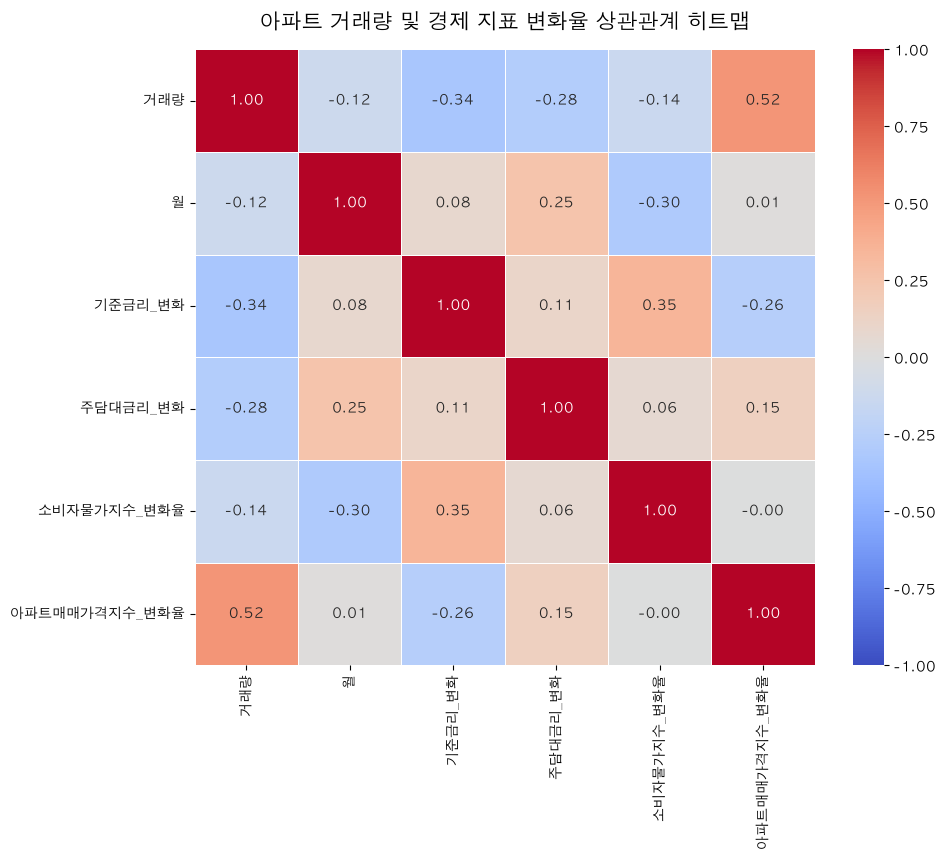

In [90]:
# 2. 상관관계 분석을 위해 X(파생변수)와 Y(거래량)를 다시 하나로 묶기
# (VIF 확인용으로 분리해두었던 정답과 힌트를 합칩니다)
df_corr = pd.concat([Y, X], axis=1)

# 합치는 과정에서 혹시 생겼을지 모를 결측치(NaN) 최종 제거
df_corr = df_corr.dropna()

# 3. 상관계수 계산 (피어슨 상관계수)
corr_matrix = df_corr.corr()

# 4. 히트맵 시각화 세팅
plt.figure(figsize=(10, 8)) # 그래프 크기 설정

# 5. 히트맵 그리기
sns.heatmap(
    corr_matrix, 
    annot=True,         # 네모 칸 안에 숫자 표시
    cmap='coolwarm',    # 색상 테마 (파랑은 음의 상관, 빨강은 양의 상관)
    fmt='.2f',          # 숫자는 소수점 둘째 자리까지만 표시
    linewidths=0.5,     # 네모 칸 사이에 얇은 선 긋기
    vmin=-1, vmax=1     # 상관계수 최소/최대 범위 고정 (-1 부터 1)
)

plt.title('아파트 거래량 및 경제 지표 변화율 상관관계 히트맵', fontsize=15, pad=15)
plt.show()

In [91]:
corr_matrix 

,거래량,월,기준금리_변화,주담대금리_변화,소비자물가지수_변화율,아파트매매가격지수_변화율
거래량,1.000000,-0.120205,-0.340536,-0.276549,-0.138981,0.519876
월,-0.120205,1.000000,0.082607,0.253811,-0.297879,0.014699
기준금리_변화,-0.340536,0.082607,1.000000,0.107073,0.347297,-0.262506
주담대금리_변화,-0.276549,0.253811,0.107073,1.000000,0.062767,0.149957
소비자물가지수_변화율,-0.138981,-0.297879,0.347297,0.062767,1.000000,-0.000754
아파트매매가격지수_변화율,0.519876,0.014699,-0.262506,0.149957,-0.000754,1.000000


In [89]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 2. X 데이터 세팅 (다중공선성 주범들 모두 제거!)
# 타겟변수(거래량)와 함께, VIF가 폭발했던 원본 지수 컬럼들을 과감히 버립니다.
# (이미 변화율 데이터를 만들었으므로 원본은 필요 없습니다)
cols_to_drop = [
    '거래량', 
    '년', 
    '기준금리', 
    '소비자물가지수', 
    '아파트 매매가격지수', 
    '주택담보대출금리' # 주담대금리 역시 '주담대금리_변화'만 남기고 버립니다.
]
X = df.drop(columns=cols_to_drop)

# 숫자형만 남기기
X = X.select_dtypes(include=[np.number])

# 3. 결측치 처리 (pct_change를 쓰면 첫 행은 무조건 NaN이 되므로 꼭 지워야 합니다)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# 4. VIF 최종 계산
if X.empty:
    print("🚨 데이터가 텅 비었습니다!")
else:
    vif = pd.DataFrame()
    vif["변수"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    
    # 내림차순 정렬
    vif = vif.sort_values("VIF", ascending=False)
    
    print("✨ 최종 VIF 결과 ✨")
    print(vif)

✨ 최종 VIF 결과 ✨
              변수       VIF
3    소비자물가지수_변화율  1.412271
0              월  1.352165
1        기준금리_변화  1.268609
4  아파트매매가격지수_변화율  1.224825
2       주담대금리_변화  1.127241


In [98]:
# 1. 삭제할 불필요한 컬럼(원본 지표, 단순 문자열 등) 리스트 작성
# 앞서 다중공선성(VIF)이 높았던 원본 변수나, 모델이 인식할 수 없는 문자열 변수를 넣습니다.
cols_to_drop = [
    '년', 
    '시도', 
    '년월',
    '기준금리', 
    '주택담보대출금리', 
    '아파트 매매가격지수', 
    '소비자물가지수'
]

# 2. 컬럼 삭제 (원본 데이터는 보호하고, 새로운 변수 model_df에 저장)
# axis=1 은 '열(컬럼)'을 기준으로 삭제하겠다는 뜻입니다.
model_df = df.drop(cols_to_drop, axis=1)

# 3. 결측치(NaN) 제거 (모델링 전 필수 단계!)
# 파생변수(변화율 등)를 만들면서 생긴 첫 번째 행의 빈칸 등을 모두 지워줍니다.
model_df = model_df.dropna()

# 4. 데이터 최종 확인
print("✨ 데이터 크기(행, 열):", model_df.shape)
print("✨ 남은 컬럼 목록:", model_df.columns.tolist())
display(model_df.head())

✨ 데이터 크기(행, 열): (76, 6)
✨ 남은 컬럼 목록: ['월', '거래량', '기준금리_변화', '주담대금리_변화', '소비자물가지수_변화율', '아파트매매가격지수_변화율']


,월,거래량,기준금리_변화,주담대금리_변화,소비자물가지수_변화율,아파트매매가격지수_변화율
1,2,8403,0.00,0.01,0.000699,0.001153
2,3,4634,-0.50,-0.04,-0.002196,0.001037
3,4,3165,0.00,0.10,-0.004403,-0.001036
4,5,5819,-0.25,-0.06,-0.000603,-0.001958
5,6,16404,0.00,-0.03,0.002715,0.001269


In [99]:
import os

# 1. 저장할 폴더 경로 설정
save_dir = '/Users/CHOIEUNSEO/Desktop/AI·AX 전문가 과정/프로젝트/data'

# 폴더가 혹시 없다면 생성해주는 코드 (안전장치)
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# 2. 최종 파일 경로 설정 (원하시는 파일명으로 변경 가능합니다)
file_path = f'{save_dir}/model_df.csv'

# 3. CSV 파일로 저장
# index=False: 데이터프레임의 인덱스 번호는 엑셀에 저장하지 않음
# encoding='utf-8-sig': 맥(Mac)과 윈도우(Windows) 어디서든 한글이 깨지지 않도록 설정
model_df.to_csv(file_path, index=False, encoding='utf-8-sig')

print(f"데이터가 성공적으로 저장되었습니다: {file_path}")

데이터가 성공적으로 저장되었습니다: /Users/CHOIEUNSEO/Desktop/AI·AX 전문가 과정/프로젝트/data/model_df.csv
